# Probability calibration

**What** — **Why** — **How**, then a complete example (Diabetes dataset) with calibration and threshold tuning, and a workflow diagram.

## What is probability calibration?

Many classifiers output **predicted probabilities** (e.g. via `predict_proba`), but those numbers are not always **reliable as probabilities**. For a **well-calibrated** classifier, when it predicts "positive with probability 0.8", about 80% of those cases should actually be positive. **Calibration** adjusts the model's scores so they can be interpreted as true confidence levels. Some models (e.g. [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)) tend to be reasonably well calibrated; others (e.g. tree-based ensembles, SVMs) often are not. scikit-learn's [calibration module](https://scikit-learn.org/stable/modules/calibration.html) lets you **recalibrate** a classifier or add probability estimates to models that don't provide them (e.g. [SGDClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html)).

## Why calibrate?

- **Threshold tuning** (e.g. with [`TunedThresholdClassifierCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html)) assumes that the numbers you threshold are meaningful. If “0.3” doesn’t correspond to ~30% chance of the positive class, the chosen threshold will be misleading.
- **Decision-making**: In applications where you use probabilities (e.g. cost-sensitive decisions, risk scores), poorly calibrated probabilities lead to worse decisions.
- **Metrics** like Brier score or log loss directly benefit from better-calibrated probabilities.

## How: calibration curves and CalibratedClassifierCV

**Checking calibration** — A **calibration curve** (reliability diagram) plots, for bins of predicted probability (x-axis), the **fraction of positives** in that bin (y-axis). On the diagonal, predicted probability matches actual frequency (well calibrated). Use [CalibrationDisplay.from_estimator](https://scikit-learn.org/stable/modules/generated/sklearn.calibration.CalibrationDisplay.html) or [calibration_curve](https://scikit-learn.org/stable/modules/generated/sklearn.calibration.calibration_curve.html).

**Recalibrating** — [CalibratedClassifierCV](https://scikit-learn.org/stable/modules/generated/sklearn.calibration.CalibratedClassifierCV.html) fits a **calibrator** that maps the base classifier's scores to probabilities. The calibrator should be fit on data **not** used to train the base model (to avoid overfitting). Passing an integer or a CV splitter (e.g. `StratifiedKFold`) uses cross-validation: each fold trains a base model and a calibrator on held-out predictions.

## Complete example: Diabetes dataset

We use the **Diabetes** dataset (imbalanced, [OpenML id=37](https://www.openml.org/d/37)) to build a robust classifier end-to-end: **pipeline → calibration → threshold tuning**, with **stratified** cross-validation at each step, and a **stratified** train/test split for final evaluation.

Load the dataset and inspect the target (slight class imbalance):

In [35]:
from sklearn.datasets import fetch_openml

data = fetch_openml(data_id=37, as_frame=True, parser="pandas")
data, target = data.data, data.target
print(target.value_counts())


class
tested_negative    500
tested_positive    268
Name: count, dtype: int64


Convert labels to 0/1 (tested_negative=0, tested_positive=1) and do a **stratified** train/test split:

In [42]:
from sklearn.model_selection import train_test_split
import numpy as np

y = target.map({"tested_negative": 0, "tested_positive": 1})
X_train, X_test, y_train, y_test = train_test_split(
    data, y, stratify=y, test_size=0.3, random_state=42
)


**Calibration curves: LogisticRegression vs SVM** — Below we compare how well two classifiers are calibrated on the same data. Logistic regression often stays close to the diagonal; SVM tends to be less well calibrated.

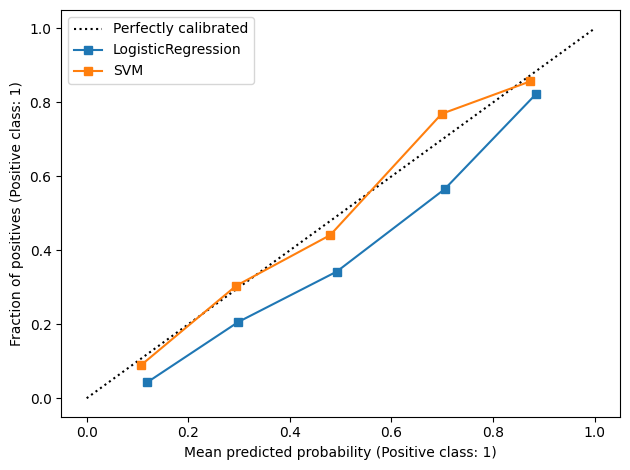

In [43]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000)),
])
pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel="linear", class_weight="balanced", probability=True)),
])
pipe_lr.fit(X_train, y_train)
pipe_svm.fit(X_train, y_train)

fig, ax = plt.subplots()
CalibrationDisplay.from_estimator(pipe_lr, X_train, y_train, ax=ax, name="LogisticRegression")
CalibrationDisplay.from_estimator(pipe_svm, X_train, y_train, ax=ax, name="SVM")
ax.legend()
plt.tight_layout()
plt.show()

**Uncalibrated vs calibrated classifier (SVM)** — The same SVM pipeline can be wrapped in `CalibratedClassifierCV` to improve probability estimates. Here we compare the raw SVM to its calibrated version.

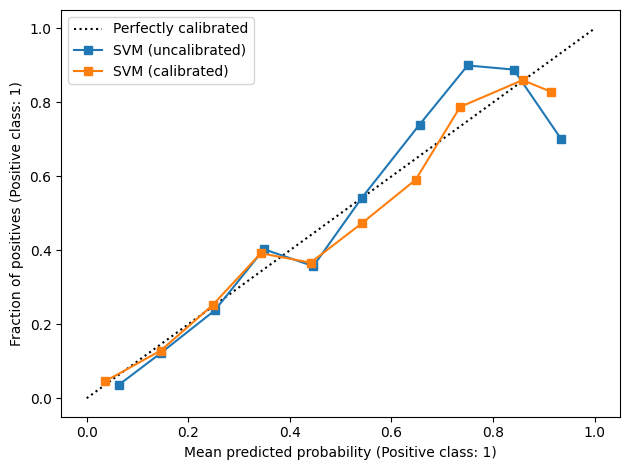

In [44]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold

svm_uncalibrated = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel="linear", class_weight="balanced", probability=True)),
])
svm_calibrated = CalibratedClassifierCV(
    estimator=svm_uncalibrated, method="isotonic", cv=StratifiedKFold(5, random_state=42, shuffle=True)
)
svm_uncalibrated.fit(X_train, y_train)
svm_calibrated.fit(X_train, y_train)

fig, ax = plt.subplots()
CalibrationDisplay.from_estimator(svm_uncalibrated, X_train, y_train, ax=ax, name="SVM (uncalibrated)", n_bins=10)
CalibrationDisplay.from_estimator(svm_calibrated, X_train, y_train, ax=ax, name="SVM (calibrated)", n_bins=10)
ax.legend()
plt.tight_layout()
plt.show()

Build the full chain: **Pipeline** (scaler + classifier) → **CalibratedClassifierCV** (stratified CV) → **TunedThresholdClassifierCV** (stratified CV). Each CV uses its own `StratifiedKFold`:

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import TunedThresholdClassifierCV, StratifiedKFold

cv_cal = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
cv_threshold = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

base_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000)),
])
calibrated = CalibratedClassifierCV(
    estimator=base_pipeline, method="isotonic", cv=cv_cal
)
tuned_model = TunedThresholdClassifierCV(
    estimator=calibrated, scoring="balanced_accuracy", cv=cv_threshold
)


Cross-validate the full model on the training set (again with **stratified** CV) to estimate performance:

In [46]:
import pandas as pd
from sklearn.model_selection import cross_validate

cv_eval = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
scoring = ["accuracy", "balanced_accuracy", "precision", "recall"]
cv_results = cross_validate(
    tuned_model, X_train, y_train,
    scoring=scoring, cv=cv_eval, return_train_score=True
)
pd.DataFrame(cv_results).agg(["mean", "std"]).T


,mean,std
fit_time,0.789930,0.153597
score_time,0.015175,0.002717
test_accuracy,0.752371,0.045709
train_accuracy,0.770029,0.027582
test_balanced_accuracy,0.732782,0.028496
train_balanced_accuracy,0.754804,0.015357
test_precision,0.671102,0.122360
train_precision,0.671439,0.064427
test_recall,0.668421,0.135925
train_recall,0.704609,0.099537


Fit on the full training set and evaluate on the **stratified** held-out test set:

In [47]:
tuned_model.fit(X_train, y_train)


,"estimator estimator: estimator instanceThe classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.",CalibratedCla...od='isotonic')
,"scoring scoring: str or callable, default=""balanced_accuracy""The objective metric to be optimized. Can be one of:- str: string associated to a scoring function for binary classification, see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.",'balanced_accuracy'
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke, for each classifier, `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"thresholds thresholds: int or array-like, default=100The number of decision threshold to use when discretizing the output of theclassifier `method`. Pass an array-like to manually specify the thresholdsto use.",100
,"cv cv: int, float, cross-validation generator, iterable or ""prefit"", default=NoneDetermines the cross-validation splitting strategy to train classifier.Possible inputs for cv are:* `None`, to use the default 5-fold stratified K-fold cross validation;* An integer number, to specify the number of folds in a stratified k-fold;* A float number, to specify a single shuffle split. The floating number should be in (0, 1) and represent the size of the validation set;* An object to be used as a cross-validation generator;* An iterable yielding train, test splits;* `""prefit""`, to bypass the cross-validation.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... warning:: Using `cv=""prefit""` and passing the same dataset for fitting `estimator` and tuning the cut-off point is subject to undesired overfitting. You can refer to :ref:`TunedThresholdClassifierCV_no_cv` for an example. This option should only be used when the set used to fit `estimator` is different from the one used to tune the cut-off point (by calling :meth:`TunedThresholdClassifierCV.fit`).",StratifiedKFo... shuffle=True)
,"refit refit: bool, default=TrueWhether or not to refit the classifier on the entire training set oncethe decision threshold has been found.Note that forcing `refit=False` on cross-validation having morethan a single split will raise an error. Similarly, `refit=True` inconjunction with `cv=""prefit""` will raise an error.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. When `cv` represents across-validation strategy, the fitting and scoring on each data splitis done in parallel. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of cross-validation when `cv` is a float.See :term:`Glossary `.",None
,"store_cv_results store_cv_results: bool, default=FalseWhether to store all scores and thresholds computed during the cross-validationprocess.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True


In [ ]:
tuned_model.score(X_test, y_test)